## SETUP

In [24]:
import numpy as np
from numpy.fft import fft2, ifft2
import scipy as sp
import sigpy
import sigpy.mri as mr
import sigpy.plot as pl
import matplotlib.pyplot as plt
import pywt

import gfloat
from gfloat.formats import *
from gfloat import decode_float

## Custom FFT using Cooley-Tukey

In [55]:
def fft1d_mixed_radix(input_array):
    """
    Perform a 1-dimensional FFT on a complex NumPy array using a mixed-radix Cooley-Tukey algorithm.

    Parameters:
        input_array (np.ndarray): A 1D complex NumPy array.

    Returns:
        np.ndarray: The 1D FFT of the input array.
    """
    N = len(input_array)
    if N <= 1:
        return input_array

    # Find the smallest factor of N
    for factor in range(2, N + 1):
        if N % factor == 0:
            break

    # Divide the array into smaller chunks based on the factor
    sub_size = N // factor
    sub_fft = np.zeros((factor, sub_size), dtype=np.complex128)
    for i in range(factor):
        sub_fft[i] = fft1d_mixed_radix(input_array[i::factor])

    # Combine results using the twiddle factors
    result = np.zeros(N, dtype=np.complex128)
    for k in range(N):
        for j in range(factor):
            twiddle = np.exp(-2j * np.pi * j * k / N)
            result[k] += sub_fft[j, k % sub_size] * twiddle

    return result




def fft2d_mixed_radix(input_array, norm):
    """
    Perform a 2-dimensional FFT on a complex NumPy array using a mixed-radix Cooley-Tukey algorithm.

    Parameters:
        input_array (np.ndarray): A 2D complex NumPy array.

    Returns:
        np.ndarray: The 2D FFT of the input array.
    """

    # Apply 1D FFT to each row
    row_fft = np.array([fft1d_mixed_radix(row) for row in input_array])

    # Apply 1D FFT to each column
    col_fft = np.array([fft1d_mixed_radix(col) for col in row_fft.T]).T

    # Apply normalization
    if norm == "forward":
        col_fft /= input_array.size  # Normalize by total number of elements
    elif norm == "ortho":
        col_fft /= np.sqrt(input_array.size)  # Normalize by sqrt of total number of elements

    return col_fft

def fft2d(input_array, norm='ortho'):
    """
    Perform a 2-dimensional FFT on the two last axis of a complex NumPy array
    """
    if input_array.ndim == 2:
        return fft2d_mixed_radix(input_array, norm)
    elif input_array.ndim == 3:
        ## Apply fft2d_mixed_radix to last 2 axes
        working_array = input_array.copy()
        for i in range(working_array.shape[0]):
            working_array[i] = fft2d_mixed_radix(working_array[i], norm)

        return working_array
    else:
        raise ValueError("Input array must be 2D or 3D.")
    
# Example usage:

# Create a sample 2D complex array (arbitrary size)
array = np.array([[1 + 1j, 2 + 2j, 3 + 3j], [4 + 4j, 5 + 5j, 6 + 6j]])

# Perform the custom mixed-radix 2D FFT
fft_result = fft2d_mixed_radix(array, norm='ortho')
print("Custom Mixed-Radix 2D FFT Result:")
print(fft_result)

# Compare with NumPy's result
numpy_result = np.fft.fft2(array, norm='ortho')
print("\nNumPy's FFT2 Result:")
print(numpy_result)

# Check the difference
difference = np.abs(fft_result - numpy_result)
print("\nDifference:")
print(difference)


Custom Mixed-Radix 2D FFT Result:
[[ 8.57321410e+00+8.57321410e+00j -1.93185165e+00-5.17638090e-01j
  -5.17638090e-01-1.93185165e+00j]
 [-3.67423461e+00-3.67423461e+00j  0.00000000e+00+8.61168638e-16j
  -1.22376596e-15+0.00000000e+00j]]

NumPy's FFT2 Result:
[[ 8.5732141 +8.5732141j  -1.93185165-0.51763809j -0.51763809-1.93185165j]
 [-3.67423461-3.67423461j  0.        +0.j          0.        +0.j        ]]

Difference:
[[0.00000000e+00 1.88737914e-15 3.87784231e-15]
 [1.77635684e-15 8.61168638e-16 1.22376596e-15]]


## Custom FP8 FFT


Norm of Difference:
86.49944147967756

Max Absolute Difference:
21.08946715780178

Machine Epsilon:  0.125


Text(0.5, 1.0, 'ocp_e5m2 - Difference between custom FP8 FFT and NumPy')

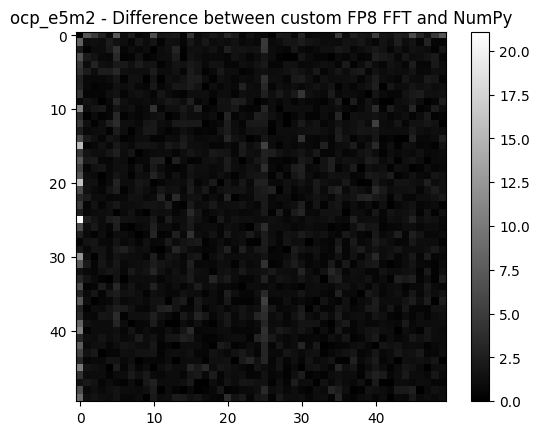

In [ ]:
# FP8 simulated arithmetic helper functions
def fp8_add(a, b, fp8_format):
    # Convert inputs to FP8 if not already (assume they are already FP8 for simplicity).
    # Perform addition in double precision
    c = a + b
    # Quantize result back to FP8
    c_fp8 = to_fp8(c, fp8_format)
    return c_fp8

def fp8_sub(a, b, fp8_format):
    c = a - b
    c_fp8 = to_fp8(c, fp8_format)
    return c_fp8

def fp8_mult(a, b, fp8_format):
    c = a * b
    c_fp8 = to_fp8(c, fp8_format)
    return c_fp8

def fp8_roll(x, shift, axis, fp8_format):
    # Roll in double precision then quantize
    xr = np.roll(x, shift, axis=axis)
    xr_fp8 = to_fp8(xr, fp8_format)
    return xr_fp8

def to_fp8(x, format):
    fp8_real = gfloat.round_ndarray(format, x.real)
    fp8_imag = gfloat.round_ndarray(format, x.imag)
    fp8_complex = fp8_real + 1j * fp8_imag
    return fp8_complex

def fft1d_mixed_radix_fp8(input_array, format):
    """
    Perform a 1-dimensional FFT on a complex NumPy array using a mixed-radix Cooley-Tukey algorithm.

    Parameters:
        input_array (np.ndarray): A 1D complex NumPy array.

    Returns:
        np.ndarray: The 1D FFT of the input array.
    """
    N = input_array.size
    if N <= 1:
        return to_fp8(input_array, format)

    # Find the smallest factor of N
    for factor in range(2, N + 1):
        if N % factor == 0:
            break

    # Divide the array into smaller chunks based on the factor
    sub_size = N // factor
    sub_fft = np.zeros((factor, sub_size), dtype=np.complex128)
    for i in range(factor):
        sub_fft[i] = to_fp8(fft1d_mixed_radix_fp8(input_array[i::factor], format), format)

    # Combine results using the twiddle factors
    result = np.zeros(N, dtype=np.complex128)
    for k in range(N):
        for j in range(factor):
            twiddle = to_fp8(np.exp(-2j * np.pi * j * k / N), format)
            result[k] = fp8_add(result[k], fp8_mult(sub_fft[j, k % sub_size], twiddle, format), format)

    return to_fp8(result, format)


def fft2d_mixed_radix_fp8(input_array, norm, format):
    """
    Perform a 2-dimensional FFT on a complex NumPy array using a mixed-radix Cooley-Tukey algorithm.

    Parameters:
        input_array (np.ndarray): A 2D complex NumPy array.

    Returns:
        np.ndarray: The 2D FFT of the input array.
    """

    # Apply 1D FFT to each row
    row_fft = np.array([fft1d_mixed_radix_fp8(row, format) for row in input_array])

    # Apply 1D FFT to each column
    col_fft = np.array([fft1d_mixed_radix_fp8(col, format) for col in row_fft.T]).T

    if norm == "forward":
        col_fft /= input_array.size  # Normalize by total number of elements
    elif norm == "ortho":
        col_fft /= np.sqrt(input_array.size)  # Normalize by sqrt of total number of elements

    return to_fp8(col_fft, format)

def fft2d_fp8(input_array, norm='ortho', format=format_info_ocp_e5m2):
    """
    Perform a 2-dimensional FFT on the two last axis of a complex NumPy array
    """
    if input_array.ndim == 2:
        return fft2d_mixed_radix_fp8(input_array, norm, format)
    elif input_array.ndim == 3:
        ## Apply fft2d_mixed_radix to last 2 axes
        working_array = input_array.copy()
        for i in range(working_array.shape[0]):
            working_array[i] = fft2d_mixed_radix_fp8(working_array[i], norm, format)

        return working_array
    else:
        raise ValueError("Input array must be 2D or 3D.")
    
# Testing
FORMAT = format_info_ocp_e5m2 # FP8 format
SCALE = 1 # Scale of the input array

# Create a sample 2D complex array uniformly distributed on the unit square [0, 1] + i[0, 1]

array = np.random.rand(50, 50) + 1j * np.random.rand(50, 50)
array *= SCALE

# Perform the custom mixed-radix 2D FFT
fft_result = fft2d_fp8(array, norm='ortho', format=FORMAT)

#print("Custom Mixed-Radix 2D FFT Result:")
#print(fft_result)

# Compare with NumPy's result
numpy_result = to_fp8(np.fft.fft2(array, norm='ortho'), format=FORMAT)
#print("\nNumPy's FFT2 rounded to FP8:")
#print(numpy_result)

# There is some error when computing the first element, so we manually set it to the correct value
#fft_result[0][0] = numpy_result[0][0]

# Check the difference
difference = np.abs(fft_result - numpy_result)
print("\nNorm of Difference:")
print(np.linalg.norm(fft_result - numpy_result))
print("\nMax Absolute Difference:")
print(np.max(difference))
p = FORMAT.precision
eps = 2**(-p)
print("\nMachine Epsilon: ", eps)
# Imview abs
plt.imshow(np.abs(difference), cmap='gray')
plt.colorbar()
plt.title('{FORMAT} - Difference between custom FP8 FFT and NumPy'.format(FORMAT=FORMAT.name))

## Testing 1D FFT stability

Text(0.5, 1.0, 'ocp_e4m3 - Max Absolute Difference vs. N')

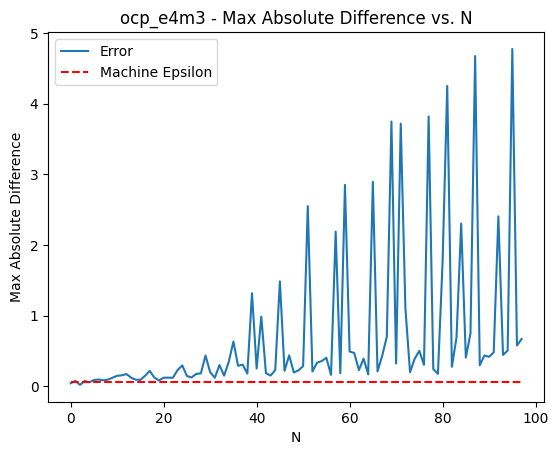

In [107]:
FORMAT = format_info_ocp_e4m3
SCALE = 1

def test(MAX_N=1000):
    error = []
    norm = "ortho"
    for N in range(2, MAX_N):
        array = SCALE * (np.random.rand(N) + 1j * np.random.rand(N))
        fft_result = fft1d_mixed_radix_fp8(array, format=FORMAT)

        if norm == "forward":
            fft_result /= array.size
        elif norm == "ortho":
            fft_result /= np.sqrt(array.size)
        
        numpy_result = to_fp8(np.fft.fft(array, norm='ortho'), format=FORMAT)
        difference = np.abs(fft_result - numpy_result)
        error.append(np.max(difference))

    return error

p = FORMAT.precision
eps = 2**(-p)
error = test(100)
plt.plot(error)
plt.plot([eps] * len(error), 'r--')
plt.legend(["Error", "Machine Epsilon"])
plt.xlabel("N")
plt.ylabel("Max Absolute Difference")
plt.title('{FORMAT} - Max Absolute Difference vs. N'.format(FORMAT=FORMAT.name))

## FULL precision

In [ ]:

SCALE = 1

def test(MAX_N=1000):
    error = []
    norm = "ortho"
    for N in range(2, MAX_N):
        array = SCALE * (np.random.rand(N) + 1j * np.random.rand(N))
        fft_result = fft1d_mixed_radix(array)

        if norm == "forward":
            fft_result /= array.size
        elif norm == "ortho":
            fft_result /= np.sqrt(array.size)
        
        numpy_result = np.fft.fft(array, norm='ortho')
        difference = np.abs(fft_result - numpy_result)
        error.append(np.max(difference))

    return error

eps = 2**(-24)
error = test(100)
plt.plot(error)
plt.plot([eps] * len(error), 'r--')
plt.legend(["Error", "Machine Epsilon"])
plt.xlabel("N")
plt.ylabel("Max Absolute Difference")
plt.title('{FORMAT} - Max Absolute Difference vs. N'.format(FORMAT=FORMAT.name))

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (4287033189.py, line 15)